# PANDAPROSUMER EXAMPLE: SIMPLE HEAT STORAGE (TWO MODES)

## DESCRIPTION
This tutorial illustrates the **Simple Heat Storage** controller, which can be used in two ways:

1. **GenericMapping (power-only)**: The storage receives and delivers power only (`q_received_kw` in; `soc`, `q_delivered_kw` out). Suitable when upstream/downstream elements work with power only.

2. **FluidMixMapping (uniform tank)**: The storage is modelled as a uniform-temperature tank with temperature and mass-flow in/out. Use when connecting to fluid-based elements (e.g. heat pump, heat demand with fluid). Optional `min_temp_c` and `max_temp_c` on the element allow SOC to be derived from tank temperature.

Time series data is defined in the notebook (no external files). After each part we run the timeseries and plot SOC and delivered power.

## Glossary
- **Network**: A configuration of connected energy generators and consumers.
- **Element**: A single generator or consumer.
- **Controller**: The logic that defines an element's behaviour.
- **Prosumer**: Container holding elements and their controllers.
- **Const Profile Controller**: Distributes time-dependent input data to element controllers.
- **Mapping**: Connection between two controllers (GenericMapping for power/data; FluidMixMapping for temperature and mass flow).

---
# Part 1: Power-only mode (GenericMapping)

Chain: **Const profile (supply power)** → **Heat storage** → **Heat demand**.

The const profile provides a supply power and demand data; the storage receives power and delivers to the demand.

In [30]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandapower.timeseries.data_sources.frame_data import DFData

current_directory = os.getcwd()
parent_directory = os.path.dirname(current_directory)
sys.path.insert(0, parent_directory)

In [31]:
# Time range and resolution
start = '2020-01-01 00:00:00'
end = '2020-01-01 23:59:59'
time_resolution_s = 900
dur = pd.date_range(start=start, end=end, freq=f'{time_resolution_s}s', tz='utc')
n_steps = len(dur)

In [32]:
# Part 1 input: supply power (to storage) and demand (for heat demand element)
supply_kw = np.zeros(n_steps)
supply_kw[0:8] = 25.0   # charge 25 kW for first 2 h
supply_kw[20:24] = 20.0 # charge again later
demand_kw = np.zeros(n_steps)
demand_kw[4:8] = 60.0   # demand spike 60 kW for 4 steps
demand_kw[12:16] = 25.0
df1 = pd.DataFrame({
    'supply_power': supply_kw,
    'demand_power': demand_kw,
    't_feed_demand_c': 80.0,
    't_return_demand_c': 20.0
}, index=dur)
profile1 = DFData(df1)
df1.head(10)

,supply_power,demand_power,t_feed_demand_c,t_return_demand_c
2020-01-01 00:00:00+00:00,25.0,0.0,80.0,20.0
2020-01-01 00:15:00+00:00,25.0,0.0,80.0,20.0
2020-01-01 00:30:00+00:00,25.0,0.0,80.0,20.0
2020-01-01 00:45:00+00:00,25.0,0.0,80.0,20.0
2020-01-01 01:00:00+00:00,25.0,60.0,80.0,20.0
2020-01-01 01:15:00+00:00,25.0,60.0,80.0,20.0
2020-01-01 01:30:00+00:00,25.0,60.0,80.0,20.0
2020-01-01 01:45:00+00:00,25.0,60.0,80.0,20.0
2020-01-01 02:00:00+00:00,0.0,0.0,80.0,20.0
2020-01-01 02:15:00+00:00,0.0,0.0,80.0,20.0


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

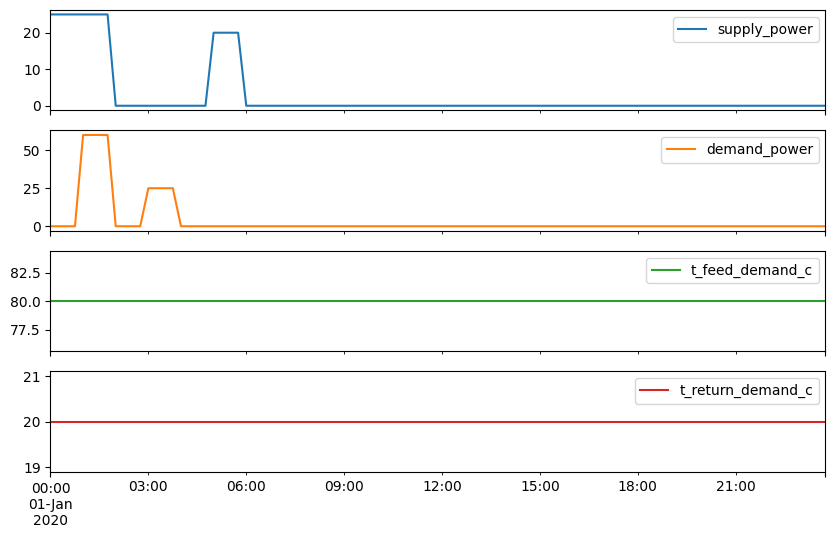

In [33]:
df1.plot(subplots=True, figsize=(10, 6))

In [34]:
from pandaprosumer.create import create_empty_prosumer_container, create_period
from pandaprosumer.create_controlled import (
    create_controlled_const_profile,
    create_controlled_heat_storage,
    create_controlled_heat_demand
)

prosumer1 = create_empty_prosumer_container()
period_id = create_period(prosumer1, time_resolution_s, start, end, 'utc', 'default')

cp_input = ['supply_power', 'demand_power', 't_feed_demand_c', 't_return_demand_c']
cp_result = ['supply_power', 'qdemand_kw', 't_feed_demand_c', 't_return_demand_c']
cp_idx = create_controlled_const_profile(prosumer1, cp_input, cp_result, profile1, period_id, 0, 0)

hs_idx = create_controlled_heat_storage(prosumer1, e_capacity_kwh=100.0, name='tank_power_only',
                                        period=period_id, level=1, order=0)
hd_idx = create_controlled_heat_demand(prosumer1, period=period_id, level=1, order=1, name='heat_consumer')

In [35]:
from pandaprosumer.mapping import GenericMapping

# Const profile -> Heat storage: supply power as q_received_kw
GenericMapping(prosumer1, initiator_id=cp_idx, initiator_column='supply_power',
               responder_id=hs_idx, responder_column='q_received_kw', order=0)
# Const profile -> Heat demand: demand request and temperatures
GenericMapping(prosumer1, initiator_id=cp_idx,
               initiator_column=['qdemand_kw', 't_feed_demand_c', 't_return_demand_c'],
               responder_id=hd_idx, responder_column=['q_demand_kw', 't_feed_demand_c', 't_return_demand_c'], order=1)
# Heat storage -> Heat demand: delivered power as q_received_kw
GenericMapping(prosumer1, initiator_id=hs_idx, initiator_column='q_delivered_kw',
               responder_id=hd_idx, responder_column='q_received_kw', order=0)

In [36]:
from pandaprosumer.run_time_series import run_timeseries

run_timeseries(prosumer1, period_id, verbose=False)

In [37]:
res1 = prosumer1.time_series.copy()

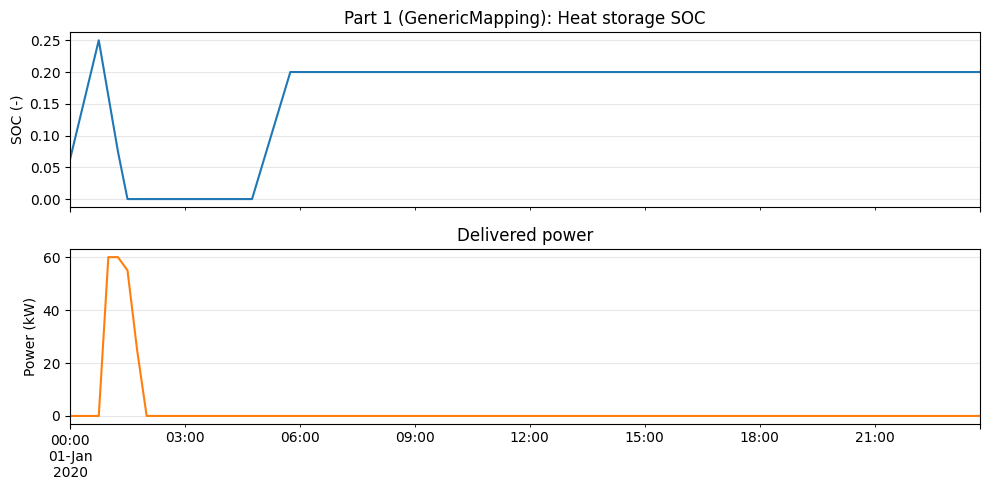

In [38]:
# time_series rows are indexed by integer; use name column to get the storage results
res1_idx = res1[res1['name'] == 'tank_power_only'].index[0]
df_hs1 = res1.data_source.loc[res1_idx].df

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
df_hs1.soc.plot(ax=axes[0], color='C0')
axes[0].set_ylabel('SOC (-)')
axes[0].set_title('Part 1 (GenericMapping): Heat storage SOC')
axes[0].grid(True, alpha=0.3)
df_hs1.q_delivered_kw.plot(ax=axes[1], color='C1')
axes[1].set_ylabel('Power (kW)')
axes[1].set_title('Delivered power')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

                           q_received_kw  q_uncovered_kw  mdot_kg_per_s  \
2020-01-01 00:00:00+00:00            0.0             0.0            0.0   
2020-01-01 00:15:00+00:00            0.0             0.0            0.0   
2020-01-01 00:30:00+00:00            0.0             0.0            0.0   
2020-01-01 00:45:00+00:00            0.0             0.0            0.0   
2020-01-01 01:00:00+00:00           60.0             0.0            0.0   
...                                  ...             ...            ...   
2020-01-01 22:45:00+00:00            0.0             0.0            0.0   
2020-01-01 23:00:00+00:00            0.0             0.0            0.0   
2020-01-01 23:15:00+00:00            0.0             0.0            0.0   
2020-01-01 23:30:00+00:00            0.0             0.0            0.0   
2020-01-01 23:45:00+00:00            0.0             0.0            0.0   

                           t_in_c  t_out_c  
2020-01-01 00:00:00+00:00     0.0      0.0  
2020-01-0

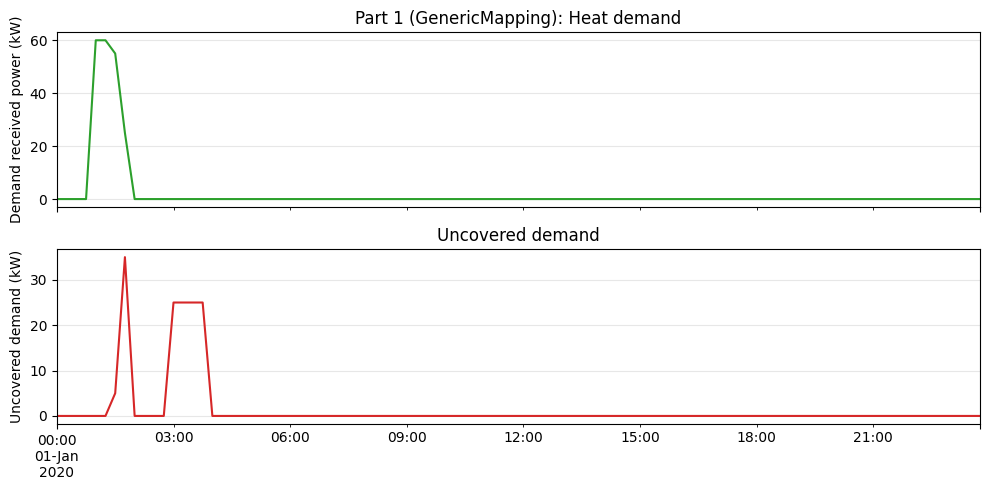

In [39]:
# heat demand results
res1_idx = res1[res1['name'] == 'heat_consumer'].index[0]
df_hd1 = res1.data_source.loc[res1_idx].df
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
print(df_hd1)
df_hd1.q_received_kw.plot(ax=axes[0], color='C2')
axes[0].set_ylabel('Demand received power (kW)')
axes[0].set_title('Part 1 (GenericMapping): Heat demand')
axes[0].grid(True, alpha=0.3)
df_hd1.q_uncovered_kw.plot(ax=axes[1], color='C3')
axes[1].set_ylabel('Uncovered demand (kW)')
axes[1].set_title('Uncovered demand')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part 2: FluidMixMapping (uniform tank)

Chain: **Const profile** → **Electric boiler** → **Heat storage (uniform tank)** → **Heat demand**.

The electric boiler supplies the storage with fluid (temperature + mass flow); the storage is configured with `capacity_kg`, optional `init_temperature_c`, `min_temp_c`, `max_temp_c` for SOC from temperature.

In [40]:
# Part 2 input: demand power and feed/return temperatures for the heat demand (same time range as Part 1)
demand_kw2 = np.zeros(n_steps)
demand_kw2[6:10] = 60.0
demand_kw2[14:18] = 30.0
t_low_c = 50.0
t_high_c = 70.0
df3 = pd.DataFrame({
    'demand_power': demand_kw2,
    't_feed_demand_c': t_high_c,
    't_return_demand_c': t_low_c
}, index=dur)
profile2 = DFData(df3)
df3.head(10)

,demand_power,t_feed_demand_c,t_return_demand_c
2020-01-01 00:00:00+00:00,0.0,70.0,50.0
2020-01-01 00:15:00+00:00,0.0,70.0,50.0
2020-01-01 00:30:00+00:00,0.0,70.0,50.0
2020-01-01 00:45:00+00:00,0.0,70.0,50.0
2020-01-01 01:00:00+00:00,0.0,70.0,50.0
2020-01-01 01:15:00+00:00,0.0,70.0,50.0
2020-01-01 01:30:00+00:00,60.0,70.0,50.0
2020-01-01 01:45:00+00:00,60.0,70.0,50.0
2020-01-01 02:00:00+00:00,60.0,70.0,50.0
2020-01-01 02:15:00+00:00,60.0,70.0,50.0


array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

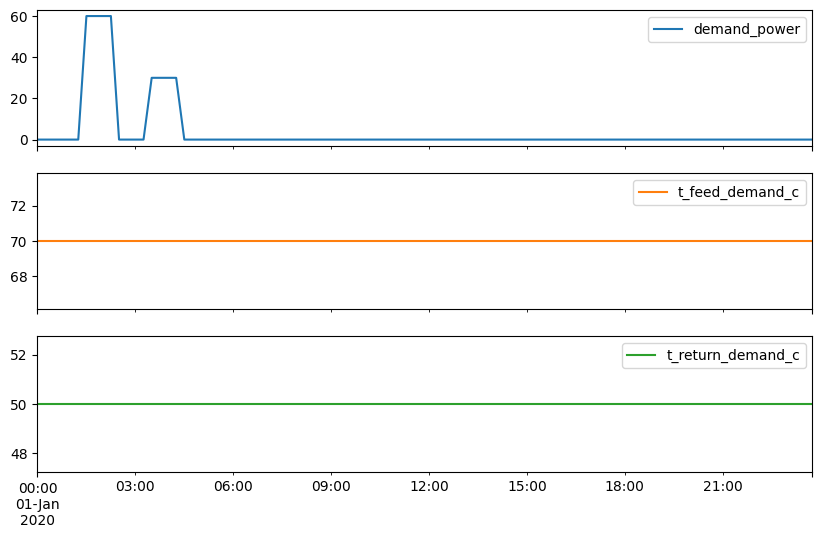

In [41]:
df3.plot(subplots=True, figsize=(10, 6))

In [42]:
from pandaprosumer.create_controlled import create_controlled_electric_boiler

prosumer3 = create_empty_prosumer_container()

time_resolution_s = 15 * 60

period_id2 = create_period(prosumer3, time_resolution_s, start, end, 'utc', 'default')

cp_input2 = ['demand_power', 't_feed_demand_c', 't_return_demand_c']
cp_result2 = ['qdemand_kw', 't_feed_demand_c', 't_return_demand_c']
cp_idx2 = create_controlled_const_profile(prosumer3, cp_input2, cp_result2, profile2, period_id2, 0, 0)

eb_max_p_kw = 50.
eb_idx = create_controlled_electric_boiler(prosumer3, max_p_kw=eb_max_p_kw, name='electric_boiler',
                                           period=period_id2, level=1, order=0)

# capacity_kg = 2000.0
# init_t = 45.0
# min_t, max_t = 30.0, 70.0
# hs_idx3 = create_controlled_heat_storage(prosumer3, name='tank_fluid_mix',
#                                          capacity_kg=capacity_kg, init_temperature_c=init_t,
#                                          min_temp_c=min_t, max_temp_c=max_t,
#                                          period=period_id2, level=1, order=1)
e_capacity_kwh = 10.0
capacity_kg = 1000.0

hs_idx3 = create_controlled_heat_storage(
    prosumer3,
    name='tank_fluid_mix',
    e_capacity_kwh=e_capacity_kwh,
    capacity_kg=capacity_kg,
    init_temperature_c=t_low_c,
    min_temp_c=t_low_c,
    max_temp_c=t_high_c,
    period=period_id2,
    level=1, order=1
)
hd_idx2 = create_controlled_heat_demand(prosumer3, period=period_id2, level=1, order=2, name='heat_consumer')

In [43]:
from pandaprosumer.mapping import GenericMapping, FluidMixMapping

# Const profile -> Heat demand: demand request and temperatures
GenericMapping(prosumer3, initiator_id=cp_idx2,
               initiator_column=['qdemand_kw', 't_feed_demand_c', 't_return_demand_c'],
               responder_id=hd_idx2, responder_column=['q_demand_kw', 't_feed_demand_c', 't_return_demand_c'], order=0)
# Electric boiler -> Heat storage: fluid (temperature + mass flow)
FluidMixMapping(prosumer3, initiator_id=eb_idx, responder_id=hs_idx3, order=0)
# Heat storage -> Heat demand: fluid (temperature + mass flow)
FluidMixMapping(prosumer3, initiator_id=hs_idx3, responder_id=hd_idx2, order=0)

In [44]:
run_timeseries(prosumer3, period_id2, verbose=False, max_iter=15, continue_on_divergence=True)

In [45]:
res2 = prosumer3.time_series.copy()

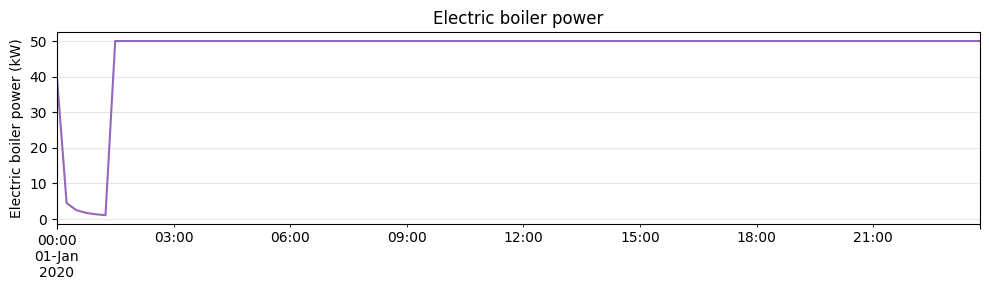

In [46]:
# Electric boiler results
res2_idx = res2[res2['name'] == 'electric_boiler'].index[0]
df_eb2 = res2.data_source.loc[res2_idx].df
fig, ax = plt.subplots(figsize=(10, 3))
df_eb2.p_kw.plot(ax=ax, color='C4')
ax.set_ylabel('Electric boiler power (kW)')
ax.set_title('Electric boiler power')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
df_eb2

,q_kw,mdot_kg_per_s,t_in_c,t_out_c,p_kw
2020-01-01 00:00:00+00:00,40.000000,0.477877,50.0,70.0,40.000000
2020-01-01 00:15:00+00:00,4.463601,0.053326,50.0,70.0,4.463601
2020-01-01 00:30:00+00:00,2.484534,0.029683,50.0,70.0,2.484534
2020-01-01 00:45:00+00:00,1.728696,0.020653,50.0,70.0,1.728696
2020-01-01 01:00:00+00:00,1.327368,0.015858,50.0,70.0,1.327368
...,...,...,...,...,...
2020-01-01 22:45:00+00:00,50.000000,0.001159,50.0,6370.0,50.000000
2020-01-01 23:00:00+00:00,50.000000,0.001141,50.0,6440.0,50.000000
2020-01-01 23:15:00+00:00,50.000000,0.001124,50.0,6510.0,50.000000
2020-01-01 23:30:00+00:00,50.000000,0.001107,50.0,6580.0,50.000000


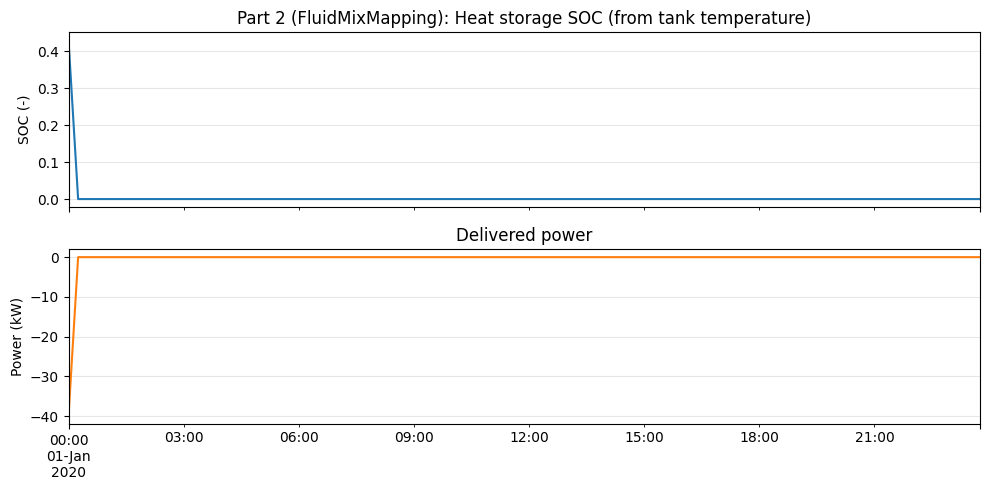

In [48]:
res2_idx = res2[res2['name'] == 'tank_fluid_mix'].index[0]
df_hs2 = res2.data_source.loc[res2_idx].df

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
df_hs2.soc.plot(ax=axes[0], color='C0')
axes[0].set_ylabel('SOC (-)')
axes[0].set_title('Part 2 (FluidMixMapping): Heat storage SOC (from tank temperature)')
axes[0].grid(True, alpha=0.3)
df_hs2.q_delivered_kw.plot(ax=axes[1], color='C1')
axes[1].set_ylabel('Power (kW)')
axes[1].set_title('Delivered power')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
df_hs2

,soc,q_delivered_kw
2020-01-01 00:00:00+00:00,0.430089,-39.965378
2020-01-01 00:15:00+00:00,0.000000,0.000000
2020-01-01 00:30:00+00:00,0.000000,0.000000
2020-01-01 00:45:00+00:00,0.000000,0.000000
2020-01-01 01:00:00+00:00,0.000000,0.000000
...,...,...
2020-01-01 22:45:00+00:00,0.000000,0.000000
2020-01-01 23:00:00+00:00,0.000000,0.000000
2020-01-01 23:15:00+00:00,0.000000,0.000000
2020-01-01 23:30:00+00:00,0.000000,0.000000


<Axes: >

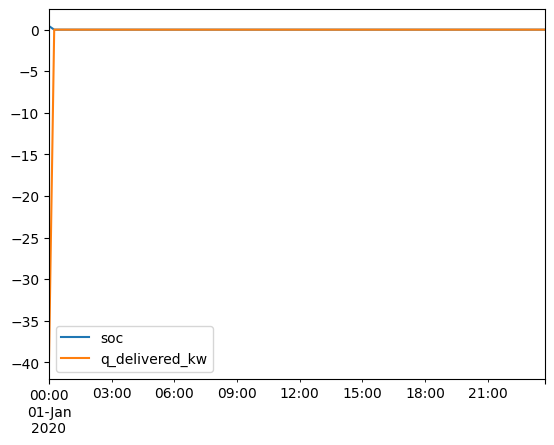

In [50]:
df_hs2.plot()

                           q_received_kw  q_uncovered_kw  mdot_kg_per_s  \
2020-01-01 00:00:00+00:00            0.0             0.0       0.477877   
2020-01-01 00:15:00+00:00            0.0             0.0       0.000000   
2020-01-01 00:30:00+00:00            0.0             0.0       0.000000   
2020-01-01 00:45:00+00:00            0.0             0.0       0.000000   
2020-01-01 01:00:00+00:00            0.0             0.0       0.000000   
...                                  ...             ...            ...   
2020-01-01 22:45:00+00:00            0.0             0.0       0.000000   
2020-01-01 23:00:00+00:00            0.0             0.0       0.000000   
2020-01-01 23:15:00+00:00            0.0             0.0       0.000000   
2020-01-01 23:30:00+00:00            0.0             0.0       0.000000   
2020-01-01 23:45:00+00:00            0.0             0.0       0.000000   

                           t_in_c  t_out_c  
2020-01-01 00:00:00+00:00    50.0     50.0  
2020-01-0

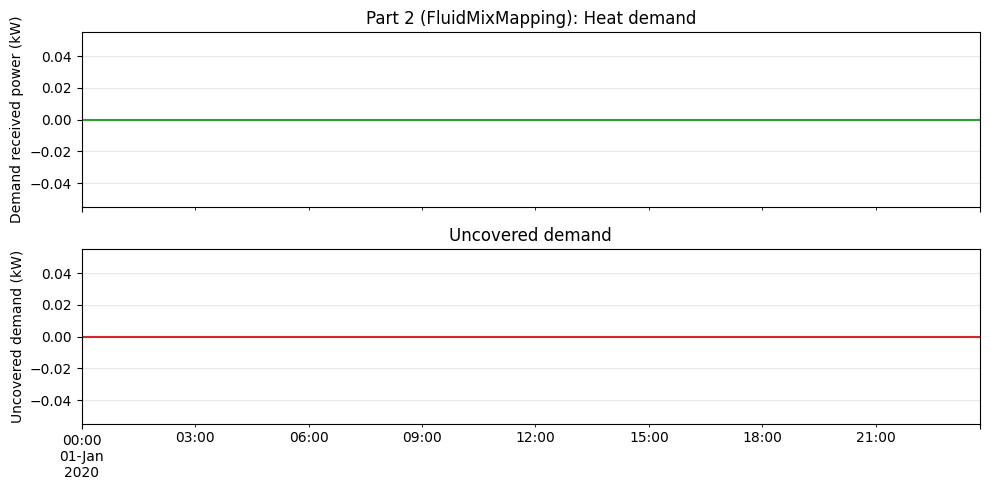

In [51]:
# Heat demand results
res2_idx = res2[res2['name'] == 'heat_consumer'].index[0]
df_hd2 = res2.data_source.loc[res2_idx].df
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
print(df_hd2)
df_hd2.q_received_kw.plot(ax=axes[0], color='C2')
axes[0].set_ylabel('Demand received power (kW)')
axes[0].set_title('Part 2 (FluidMixMapping): Heat demand')
axes[0].grid(True, alpha=0.3)
df_hd2.q_uncovered_kw.plot(ax=axes[1], color='C3')
axes[1].set_ylabel('Uncovered demand (kW)')
axes[1].set_title('Uncovered demand')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: >

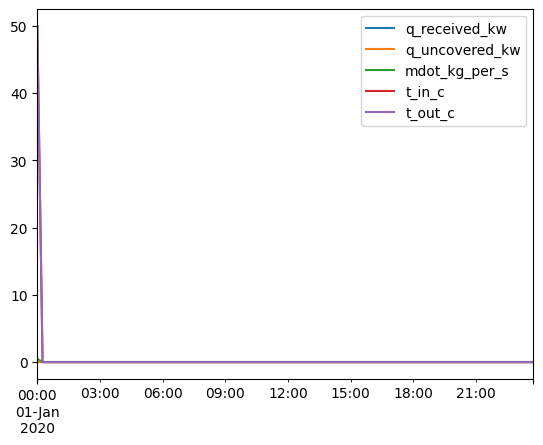

In [52]:
df_hd2.plot()

In [53]:
df_hd2

,q_received_kw,q_uncovered_kw,mdot_kg_per_s,t_in_c,t_out_c
2020-01-01 00:00:00+00:00,0.0,0.0,0.477877,50.0,50.0
2020-01-01 00:15:00+00:00,0.0,0.0,0.000000,0.0,0.0
2020-01-01 00:30:00+00:00,0.0,0.0,0.000000,0.0,0.0
2020-01-01 00:45:00+00:00,0.0,0.0,0.000000,0.0,0.0
2020-01-01 01:00:00+00:00,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...
2020-01-01 22:45:00+00:00,0.0,0.0,0.000000,0.0,0.0
2020-01-01 23:00:00+00:00,0.0,0.0,0.000000,0.0,0.0
2020-01-01 23:15:00+00:00,0.0,0.0,0.000000,0.0,0.0
2020-01-01 23:30:00+00:00,0.0,0.0,0.000000,0.0,0.0


---
# Part 2b: FluidMixMapping (uniform tank, direct example)

In this section we isolate the uniform tank behaviour and drive it directly with a
prescribed mass flow and inlet temperature, without coupling to a full boiler–storage–demand
network. This avoids FluidMix convergence issues and makes the charging / discharging
behaviour clearly visible.

We consider:

- A water tank with a given mass `capacity_kg` and initial temperature.
- A **charging phase**: hot water in, the tank heats up and SOC increases (negative `q_delivered_kw`,
  i.e. heat is stored in the tank).
- A **discharging phase**: colder water in, the tank cools down and SOC decreases (positive
  `q_delivered_kw`, i.e. heat is delivered from the tank).


In [54]:
from pandaprosumer import create_empty_prosumer_container, create_period, create_controlled_heat_storage
from pandaprosumer.mapping.fluid_mix import FluidMixMapping

prosumer3 = create_empty_prosumer_container(fluid="water")
resol_s = 15 * 60

start3 = "2020-01-01 00:00:00"
end3 = "2020-01-01 05:59:59"
period3 = create_period(
    prosumer3,
    resol_s,
    name="fluidmix_tank",
    start=start3,
    end=end3,
    timezone="utc",
)

e_capacity_kwh = 10.0
capacity_kg = 1000.0
t_low_c = 50.0
t_high_c = 70.0

hs_idx3 = create_controlled_heat_storage(
    prosumer3,
    e_capacity_kwh=e_capacity_kwh,
    capacity_kg=capacity_kg,
    init_temperature_c=t_low_c,
    min_temp_c=t_low_c,
    max_temp_c=t_high_c,
    period=period3,
)
ctrl2 = prosumer3.controller.iloc[hs_idx3].object

In [55]:
import numpy as np
import pandas as pd

# Build a simple charge (hot in) then discharge (cold in) profile

times2 = pd.date_range(start=start3, end=end3, freq=f"{resol_s}s", tz="utc", inclusive="left")

mdot2 = np.zeros(len(times2))
t_in2 = np.full(len(times2), t_low_c)

half2 = len(times2) // 2
# Charge phase: 0.5 kg/s at 70°C
mdot2[:half2] = 0.5
t_in2[:half2] = t_high_c
# Discharge phase: 0.5 kg/s at 50°C
mdot2[half2:] = 0.5
t_in2[half2:] = t_low_c

results2 = []
for ts, md, ti in zip(times2, mdot2, t_in2):
    ctrl2.time_step(prosumer3, ts)
    ctrl2.input_mass_flow_with_temp = {
        FluidMixMapping.TEMPERATURE_KEY: float(ti),
        FluidMixMapping.MASS_FLOW_KEY: float(md),
    }
    ctrl2.control_step(prosumer3)
    soc, qk = ctrl2.step_results[0]
    results2.append(
        {
            "time": ts,
            "soc": soc,
            "q_delivered_kw": qk,
            "t_tank_c": ctrl2.last_result.get("temperature", np.nan),
            "mdot_kg_per_s": ctrl2.last_result.get("mdot_kg_per_s", np.nan),
        }
    )

df_hs2 = pd.DataFrame(results2).set_index("time")
df_hs2.head()

,soc,q_delivered_kw,t_tank_c,mdot_kg_per_s
time,,,,
2020-01-01 00:00:00+00:00,0.450000,-41.815540,59.000000,0.5
2020-01-01 00:15:00+00:00,0.697500,-23.016367,63.950000,0.5
2020-01-01 00:30:00+00:00,0.833625,-12.666253,66.672500,0.5
2020-01-01 00:45:00+00:00,0.908494,-6.968749,68.169875,0.5
2020-01-01 01:00:00+00:00,0.949672,-3.833511,68.993431,0.5


In [56]:
mdot2

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

In [57]:
t_in2

array([70., 70., 70., 70., 70., 70., 70., 70., 70., 70., 70., 70., 50.,
       50., 50., 50., 50., 50., 50., 50., 50., 50., 50., 50.])

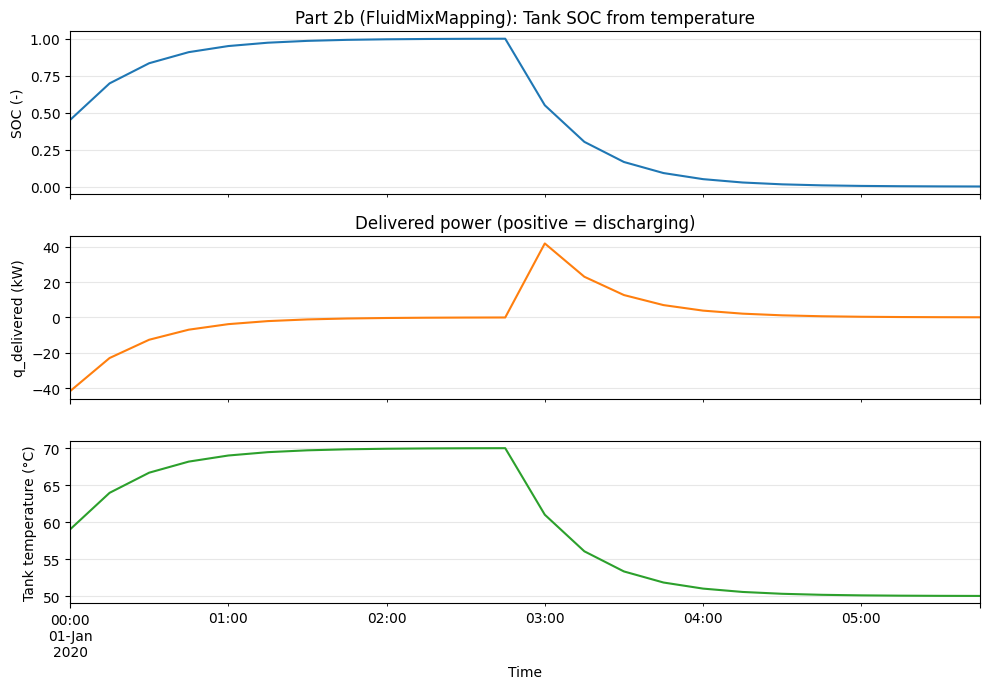

In [58]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

df_hs2["soc"].plot(ax=axes[0], color="C0")
axes[0].set_ylabel("SOC (-)")
axes[0].set_title("Part 2b (FluidMixMapping): Tank SOC from temperature")
axes[0].grid(True, alpha=0.3)

df_hs2["q_delivered_kw"].plot(ax=axes[1], color="C1")
axes[1].set_ylabel("q_delivered (kW)")
axes[1].set_title("Delivered power (positive = discharging)")
axes[1].grid(True, alpha=0.3)

df_hs2["t_tank_c"].plot(ax=axes[2], color="C2")
axes[2].set_ylabel("Tank temperature (°C)")
axes[2].set_xlabel("Time")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()